<a href="https://colab.research.google.com/github/Julss1195/Julss1195/blob/main/Customer_Clustering_and_Segmentation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from scipy.cluster.hierarchy import dendrogram, linkage
data = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/ML WORK/customer_data.csv')

In [18]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [29]:
data.shape[1]
data.head()

,Age,Annual Income (USD),Spending Score (1-100),Customer Loyalty Score,Number of Purchases,Gender,Preferred Product Category
0,44,85847,89,72,34,Male,Groceries
1,35,91873,76,78,39,Male,Electronics
2,31,99118,97,96,38,Male,Groceries
3,38,104490,89,75,49,Male,Sports
4,38,113841,62,77,34,Male,Groceries


In [39]:
Annual_Income_Round = data['Annual Income (USD)'].round(-3)
data.head()

,Age,Annual Income (USD),Spending Score (1-100),Customer Loyalty Score,Number of Purchases,Gender,Preferred Product Category
0,44,86000,89,72,34,Male,Groceries
1,35,92000,76,78,39,Male,Electronics
2,31,99000,97,96,38,Male,Groceries
3,38,104000,89,75,49,Male,Sports
4,38,114000,62,77,34,Male,Groceries


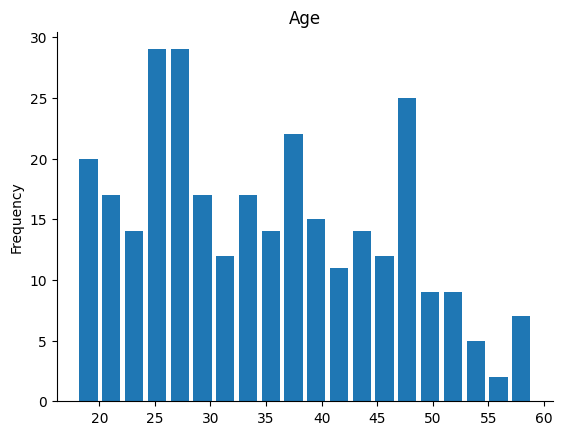

In [41]:
from matplotlib import pyplot as plt
data['Age'].plot(kind='hist', bins=20, title='Age', rwidth=0.8)
plt.gca().spines[['top', 'right',]].set_visible(False)

In [42]:
# Convert categorical variables (Gender, Preferred Product Category) to numerical values
data_encoded = pd.get_dummies(data, columns=['Gender', 'Preferred Product Category'], drop_first=True)

# Standardize the numeric data
scaler = StandardScaler()
data_scaled = scaler.fit_transform(data_encoded)



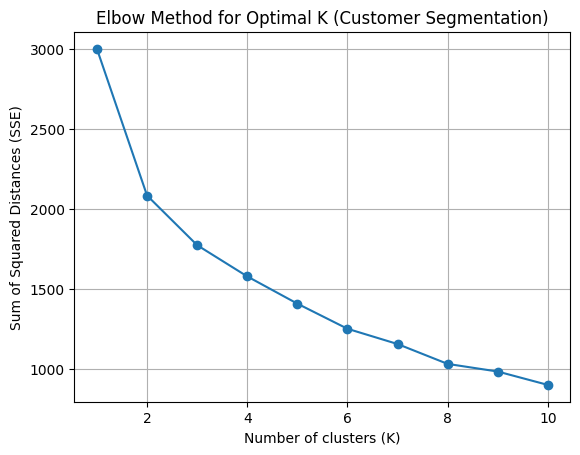

In [51]:
# K-Means Clustering with Elbow Method
sse = []
k_values = range(1, 11)
for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(data_scaled)
    sse.append(kmeans.inertia_)

# Plot the elbow graph
plt.plot(k_values, sse, marker='o')
plt.title('Elbow Method for Optimal K (Customer Segmentation)')
plt.xlabel('Number of clusters (K)')
plt.ylabel('Sum of Squared Distances (SSE)')
plt.grid(True)
plt.show()




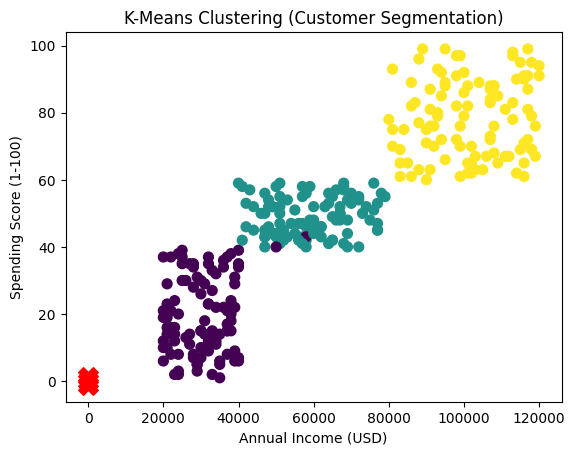

In [52]:
# Apply K-Means with the optimal number of clusters (assuming K=3 from elbow method)
kmeans = KMeans(n_clusters=3, random_state=42)
data['Cluster'] = kmeans.fit_predict(data_scaled)

# Visualize clusters based on income and spending score
plt.scatter(data['Annual Income (USD)'], data['Spending Score (1-100)'], c=data['Cluster'], s=50, cmap='viridis')
plt.scatter(kmeans.cluster_centers_[:, 1], kmeans.cluster_centers_[:, 2], s=200, c='red', marker='X')
plt.title('K-Means Clustering (Customer Segmentation)')
plt.xlabel('Annual Income (USD)')
plt.ylabel('Spending Score (1-100)')
plt.show()



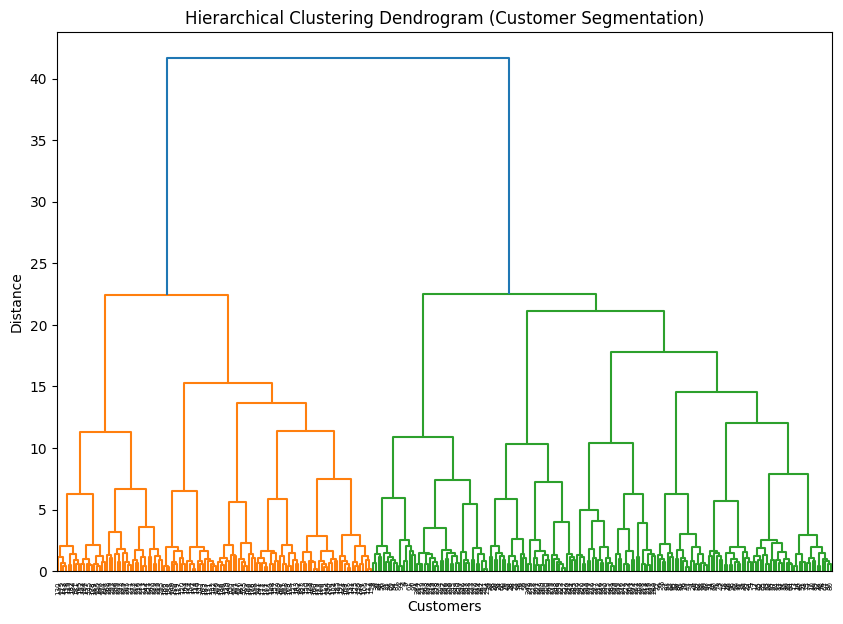

In [45]:
# Perform Hierarchical Clustering (Agglomerative)
Z = linkage(data_scaled, method='ward')

# Visualize the Dendrogram for Hierarchical Clustering
plt.figure(figsize=(10, 7))
dendrogram(Z)
plt.title('Hierarchical Clustering Dendrogram (Customer Segmentation)')
plt.xlabel('Customers')
plt.ylabel('Distance')
plt.show()